In [3]:
import yfinance as yf 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [31]:
data=yf.download('AAPL', start='2022-01-01', end='2023-01-01')
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,177.786392,178.636214,173.586187,173.703398,104487900
2022-01-04,175.529999,178.694819,174.963456,178.392015,99310400
2022-01-05,170.860886,175.989057,170.587384,175.442054,94537600
2022-01-06,168.008667,171.232092,167.657020,168.692420,96904000
2022-01-07,168.174744,170.099030,167.061198,168.878037,86709100


In [32]:
def calculate_rsi(series, period=14):
    delta=series.diff()
    gain=(delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss=(-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs=gain/loss
    return 100-(100/(1+rs))
data['RSI']=calculate_rsi(data['Close'])

In [33]:
data['Signal']=0
data.loc[data['RSI']<30, 'Signal']=1
data.loc[data['RSI']>70, 'Signal']=-1
data['Position']=data['Signal'].diff()

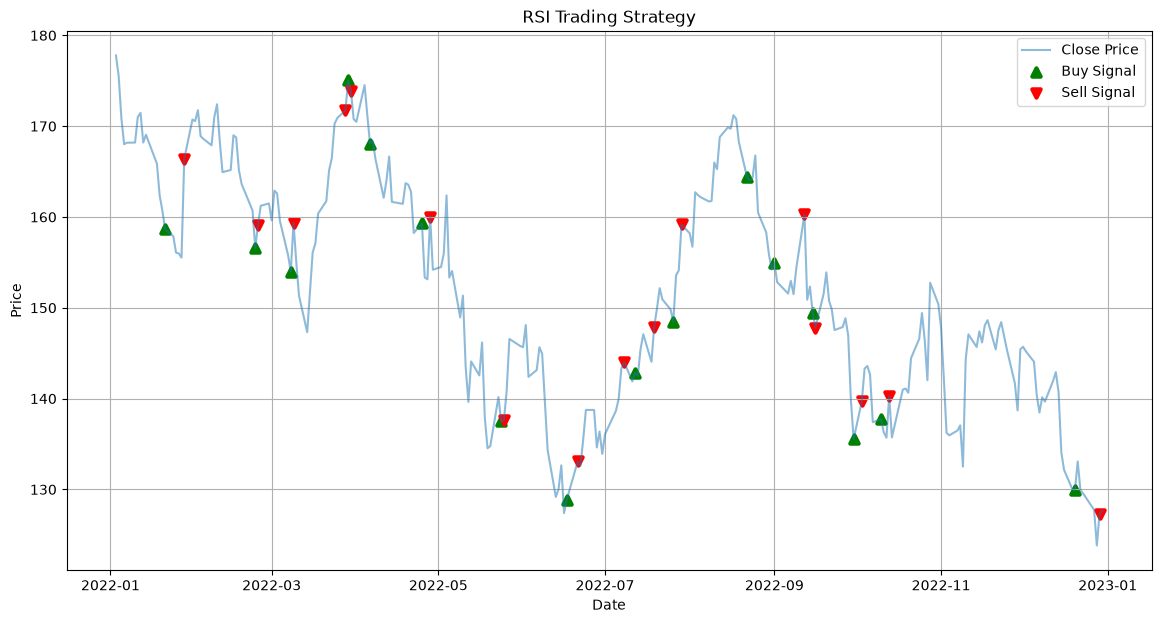

In [34]:
plt.figure(figsize=(14, 7))
plt.plot(data['Close'], label='Close Price', alpha=0.5)
plt.scatter(data.index[data['Position']==1], 
            data['Close'][data['Position']==1],
            label='Buy Signal', marker='^', color='green', lw=3)
plt.scatter(data.index[data['Position']==-1], 
            data['Close'][data['Position']==-1],
            label='Sell Signal', marker='v', color='red', lw=3)
plt.title('RSI Trading Strategy')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

